In [ ]:
import matplotlib.pyplot as plt # For ploting field
import matplotlib.image as mpimg
import matplotlib.cm as cm
from os.path import isfile

import larp # Our tool [pip install Larp]
import larp.io as lpio 
import numpy as np

import osmnx as ox # Used to load building data based on location [pip install osmnx]

edges = [0.01, 0.2, 0.5, 0.8]
penalty_scaler = lambda p: 1/(1.1*(1.0 - p + 1e-10))

address = "Purdue University, West Lafayette, IN 47907"
distance_from_address = 1000

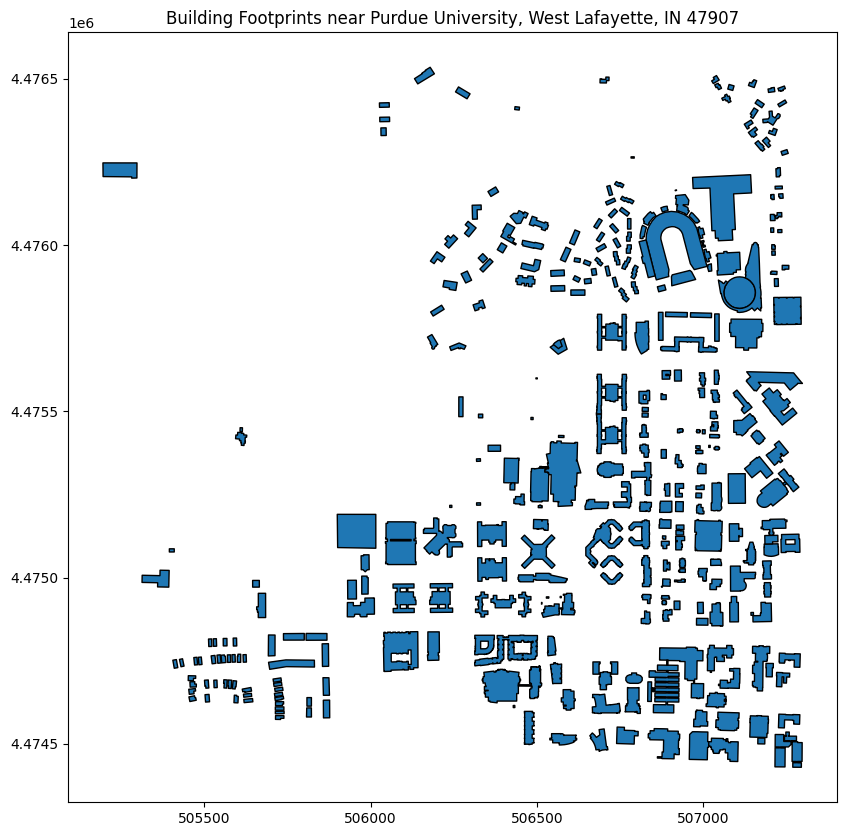

In [2]:
# Define the address and search radius
buildings = ox.features_from_address(address, tags={'building': True}, dist=distance_from_address)

# Optional: filter for Polygon geometries and project
buildings = buildings[buildings.geometry.geom_type == 'Polygon']
buildings = ox.projection.project_gdf(buildings)
west, south, east, north = buildings.total_bounds

# Plotting
fig, ax = plt.subplots(figsize=(10, 10))
buildings.plot(ax=ax, edgecolor='black')
ax.set_title(f'Building Footprints near {address}')
plt.show()

In [ ]:
# First time, it will be a bit slow since it needs to build the quadtree
if isfile('map.quad.lp'):
    quadtree, field = lpio.loadQuadTreeFile('map.quad.lp', return_field=True)
else:
    # Convert to GeoJSON
    field = lpio.loadGeoJSON(buildings.to_json())
    field.set_all_repulsion([[25.0, 0.0], [0.0, 25.0]])

    field.reload_center_point(False)
    field.size = np.array((east - west, north-south))
    field.center_point = np.array(((east + west)/2.0, (north + south)/2.0))

    quadtree = larp.quad.QuadTree(field, minimum_length_limit=2.5, edge_bounds=edges, build_tree=True)
    lpio.saveQuadTree(quadtree, file='map.quad.lp')

planner = larp.pp.QuadPlanner(quadtree) # To generate paths in map
planner.select_alg('a*')

qfield = larp.QPotentailField(quadtree) # To speed up calculations and sinc quadtree and potential field

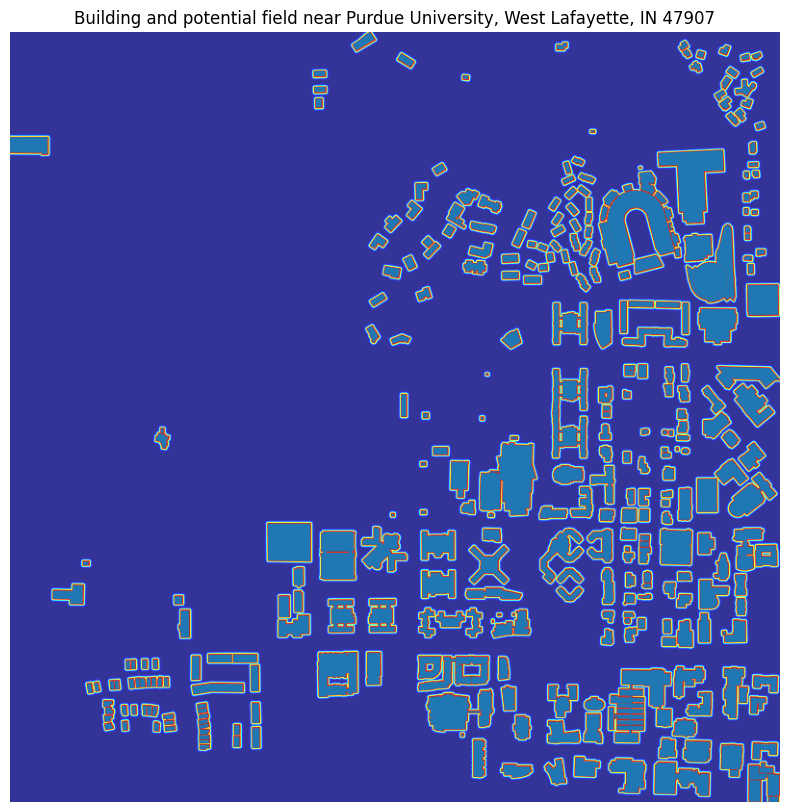

In [49]:
margin = 0.0
display, extent = qfield.to_image(resolution=800, margin=margin, max_depth=5)

# Plot potential field
fig, ax = plt.subplots(figsize=(10, 10))
ax.set_title(f'Building and potential field near {address}')
buildings.plot(ax=ax, zorder=2)
img = ax.imshow(display, cmap='jet', extent=extent, alpha=0.8, zorder=1)
ax.axis(False)
img.set_clim(0.0, 1.0)
plt.show()

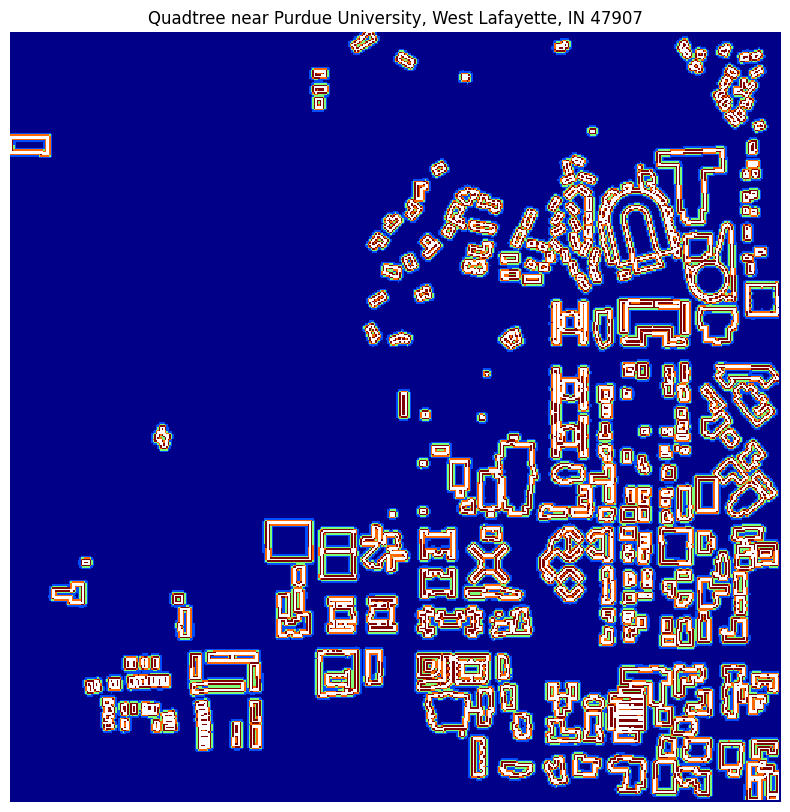

In [19]:
display_q, extent_q = quadtree.to_image(return_extent=True)

# Plot the quad sectors image
fig, ax = plt.subplots(figsize=(10, 10))
ax.set_title(f'Quadtree near {address}')
img = ax.imshow(display_q, cmap='jet', extent=extent_q, interpolation='nearest')
ax.axis(False)
img.set_clim(0.0, 1.0)
plt.show()

In [44]:
def nearest_neighbor_tsp(points):
    n = len(points)
    visited = [0]
    unvisited = set(range(1, n))
    while unvisited:
        last = points[visited[-1]]
        next_i = min(unvisited, key=lambda i: np.linalg.norm(points[i] - last))
        visited.append(next_i)
        unvisited.remove(next_i)
    return points[visited + [visited[0]]]

locations = np.random.random((10, 2))*field.size + np.array([west, south])

locations = nearest_neighbor_tsp(locations)
starts, ends = locations[:-1], locations[1:]

In [ ]:
paths = []

for start, end in zip(starts, ends):
    locations_rgj = list(qfield.find_bbox(start)) + list(qfield.find_bbox(end))

    if len(locations_rgj): dropped_field = qfield.delRGJ(locations_rgj, pop_field=True)
    path = planner.find_path(start, end, scaler=penalty_scaler)
    if len(locations_rgj): qfield.addField(dropped_field)
    
    paths.append(path)

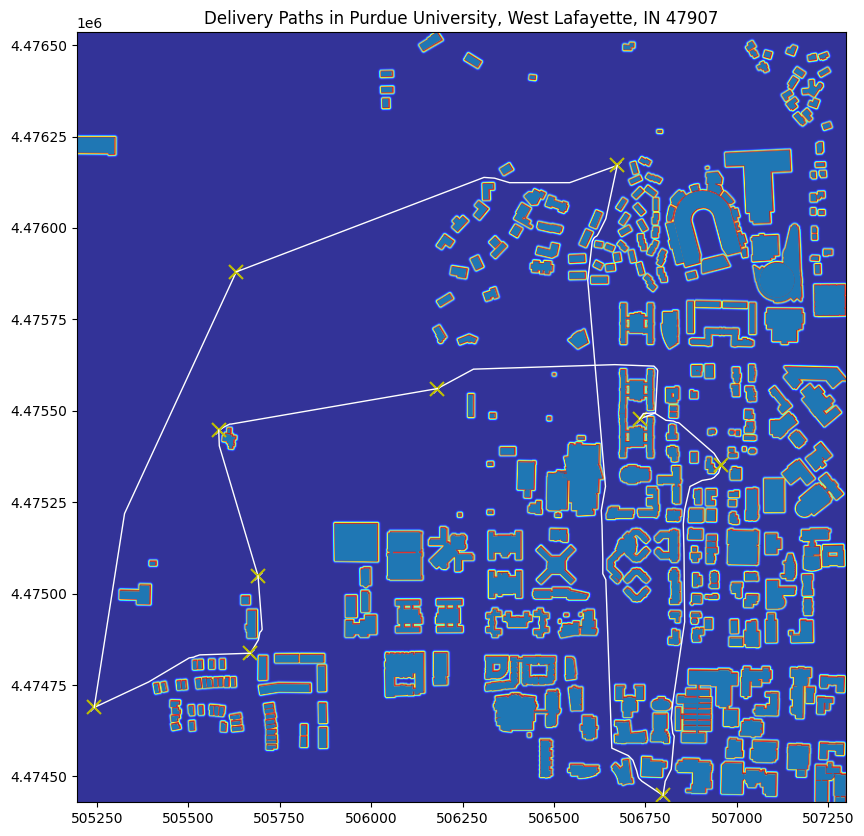

In [52]:
fig, ax = plt.subplots(figsize=(10, 10))
buildings.plot(ax=ax, zorder=2)
ax.imshow(display, cmap='jet', extent=extent, alpha=0.8)
ax.set_title(f'Delivery Paths in {address}')

for path, start, end in zip(paths, starts, ends):

    if path is None:
        ax.plot(start[0], start[1], 'rx')
        ax.plot(end[0], end[1], 'r4')
    else:
        ax.plot(path[:, 0], path[:, 1], color="#fff", alpha=1.0, linewidth=1.0)
        # plt.plot(path[0, 0], path[0, 1], 'r4', markersize=10.0, markeredgewidth=1.5)
        ax.plot(path[-1, 0], path[-1, 1], 'wx')
        ax.plot(end[0], end[1], 'yx', markersize=10.0, markeredgewidth=1.5)

img.set_clim(0.0, 1.0)
plt.show()